# BCG X Data Science Job Simulation
## Task 3: Exploratory Data Analysis (EDA)

**Client:** PowerCo — Gas & Electricity Utility  
**Objective:** Investigate price sensitivity as a driver of churn  
**Author:** Devesh Shukla  
**Date:** March 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['font.size']       = 11
sns.set_palette('Set2')

print("Libraries imported successfully!")
print(f"Analysis started: {datetime.now().strftime('%d-%m-%Y %H:%M')}")

Libraries imported successfully!
Analysis started: 23-03-2026 07:44


## 1. Loading the Data

Loading the two datasets provided by PowerCo:
- **client_data**: Historical customer information including usage, contract details and churn indicator
- **price_data**: Historical variable and fixed pricing data at different time periods

In [2]:
# Load datasets
client_df = pd.read_csv('client_data (1).csv')
price_df  = pd.read_csv('price_data (1).csv')

print("Data loaded successfully!")
print(f"\nClient Data  : {client_df.shape[0]:,} rows | {client_df.shape[1]} columns")
print(f"Price Data   : {price_df.shape[0]:,} rows  | {price_df.shape[1]} columns")

Data loaded successfully!

Client Data  : 14,606 rows | 26 columns
Price Data   : 193,002 rows  | 8 columns


## 2. Data Overview — Client Data

Let's take a first look at the client dataset to understand 
its structure, column names and data types.

In [3]:
# First look at client data
print("CLIENT DATA — First 5 rows:")
display(client_df.head())

print("\nCLIENT DATA — Shape:")
print(f"Rows: {client_df.shape[0]:,} | Columns: {client_df.shape[1]}")

print("\nCLIENT DATA — Data Types:")
print(client_df.dtypes)

print("\nCLIENT DATA — Missing Values:")
missing = client_df.isnull().sum()
missing_pct = (missing / len(client_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0])

CLIENT DATA — First 5 rows:


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0



CLIENT DATA — Shape:
Rows: 14,606 | Columns: 26

CLIENT DATA — Data Types:
id                                 object
channel_sales                      object
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                         object
date_end                           object
date_modif_prod                    object
date_renewal                       object
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                            object
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64


,Missing Count,Missing %


## 3. Data Overview — Price Data

Now let's examine the price dataset to understand its 
structure, data types and missing values.

In [4]:
# First look at price data
print("PRICE DATA — First 5 rows:")
display(price_df.head())

print("\nPRICE DATA — Shape:")
print(f"Rows: {price_df.shape[0]:,} | Columns: {price_df.shape[1]}")

print("\nPRICE DATA — Data Types:")
print(price_df.dtypes)

print("\nPRICE DATA — Missing Values:")
missing_p = price_df.isnull().sum()
missing_pct_p = (missing_p / len(price_df) * 100).round(2)
missing_df_p = pd.DataFrame({
    'Missing Count' : missing_p,
    'Missing %'     : missing_pct_p
})
display(missing_df_p[missing_df_p['Missing Count'] > 0])

PRICE DATA — First 5 rows:


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0



PRICE DATA — Shape:
Rows: 193,002 | Columns: 8

PRICE DATA — Data Types:
id                     object
price_date             object
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

PRICE DATA — Missing Values:


,Missing Count,Missing %


## 4. Descriptive Statistics

Let's look at the basic statistical properties of both datasets.
This will help us understand the range, mean, and distribution 
of key numerical columns.

In [5]:
# Descriptive statistics — Client Data
print("CLIENT DATA — Descriptive Statistics:")
display(client_df.describe().round(2))

print("\nPRICE DATA — Descriptive Statistics:")
display(price_df.describe().round(2))

CLIENT DATA — Descriptive Statistics:


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.0
mean,159220.29,28092.38,16090.27,1868.61,1399.76,0.97,63.09,0.14,0.05,43.13,152.79,24.57,24.56,1.29,189.26,5.00,18.14,0.1
std,573465.26,162973.06,64364.20,2387.57,3247.79,5.11,66.17,0.02,0.05,4.49,341.37,20.23,20.23,0.71,311.80,1.61,13.53,0.3
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,3.30,0.0
25%,5674.75,0.00,0.00,495.00,0.00,0.00,16.18,0.12,0.00,40.61,0.00,14.28,14.28,1.00,50.71,4.00,12.50,0.0
50%,14115.50,0.00,792.50,1112.88,314.00,0.00,18.80,0.14,0.08,44.31,37.39,21.64,21.64,1.00,112.53,5.00,13.86,0.0
75%,40763.75,0.00,3383.00,2401.79,1745.75,0.00,131.03,0.15,0.10,44.31,193.98,29.88,29.88,1.00,243.10,6.00,19.17,0.0
max,6207104.00,4154590.00,771203.00,82902.83,175375.00,30.00,599.31,0.27,0.20,59.27,15042.79,374.64,374.64,32.00,24570.65,13.00,320.00,1.0



PRICE DATA — Descriptive Statistics:


,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.00,193002.00,193002.00,193002.00,193002.00,193002.00
mean,0.14,0.05,0.03,43.33,10.62,6.41
std,0.03,0.05,0.04,5.41,12.84,7.77
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.13,0.00,0.00,40.73,0.00,0.00
50%,0.15,0.09,0.00,44.27,0.00,0.00
75%,0.15,0.10,0.07,44.44,24.34,16.23
max,0.28,0.23,0.11,59.44,36.49,17.46


## 5. Churn Analysis

Let's understand the overall churn rate in the dataset.
This is our target variable — how many customers have churned 
vs retained over the next 3 months.

CHURN DISTRIBUTION:
  Retained (0) : 13,187 customers (90.3%)
  Churned  (1) : 1,419 customers (9.7%)
  Total        : 14,606 customers


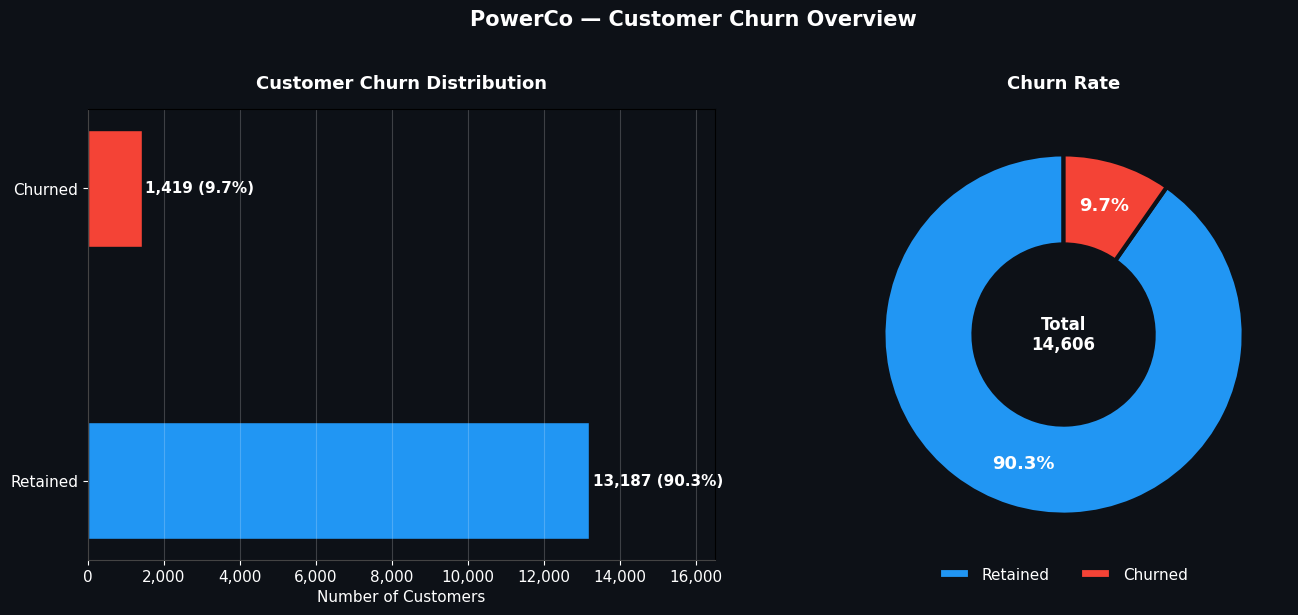

In [6]:
# Churn distribution
churn_counts = client_df['churn'].value_counts()
churn_pct    = client_df['churn'].value_counts(normalize=True) * 100

print("CHURN DISTRIBUTION:")
print(f"  Retained (0) : {churn_counts[0]:,} customers ({churn_pct[0]:.1f}%)")
print(f"  Churned  (1) : {churn_counts[1]:,} customers ({churn_pct[1]:.1f}%)")
print(f"  Total        : {len(client_df):,} customers")

# Professional Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.tick_params(colors='white')

# Plot 1 — Horizontal Bar Chart
colors      = ['#2196F3', '#F44336']
labels      = ['Retained', 'Churned']
bars = axes[0].barh(labels, churn_counts.values,
                    color=colors, edgecolor='#0D1117',
                    height=0.4)
axes[0].set_title('Customer Churn Distribution',
                   fontsize=13, fontweight='bold',
                   color='white', pad=15)
axes[0].set_xlabel('Number of Customers', color='white')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({pct:.1f}%)',
                 va='center', color='white',
                 fontweight='bold', fontsize=11)
axes[0].set_xlim(0, max(churn_counts.values) * 1.25)
axes[0].grid(axis='x', alpha=0.2, color='white')

# Plot 2 — Donut Chart
wedge_props = {'width': 0.5, 'edgecolor': '#0D1117', 'linewidth': 3}
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels      = None,
    autopct     = '%1.1f%%',
    colors      = colors,
    startangle  = 90,
    wedgeprops  = wedge_props,
    pctdistance = 0.75
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

# Center text
axes[1].text(0, 0, f'Total\n{len(client_df):,}',
             ha='center', va='center',
             color='white', fontsize=12,
             fontweight='bold')

axes[1].set_title('Churn Rate',
                   fontsize=13, fontweight='bold',
                   color='white', pad=15)

# Legend
axes[1].legend(labels, loc='lower center',
               bbox_to_anchor=(0.5, -0.08),
               ncol=2, frameon=False,
               labelcolor='white', fontsize=11)

plt.suptitle('PowerCo — Customer Churn Overview',
             fontsize=15, fontweight='bold',
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150,
            bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

### Key Finding — Churn Distribution

- **90.3%** of PowerCo customers were **retained** over the next 3 months
- **9.7%** of customers **churned** — equivalent to 1,419 customers
- This is a moderately imbalanced dataset — we will need to account 
  for this during modeling (e.g. using class weights or SMOTE)
- With ~1 in 10 customers churning, there is a significant business 
  risk that needs to be addressed urgently

## 6. Energy Consumption Analysis

Let's analyze the electricity and gas consumption patterns 
of churned vs retained customers to see if there are any 
notable differences.

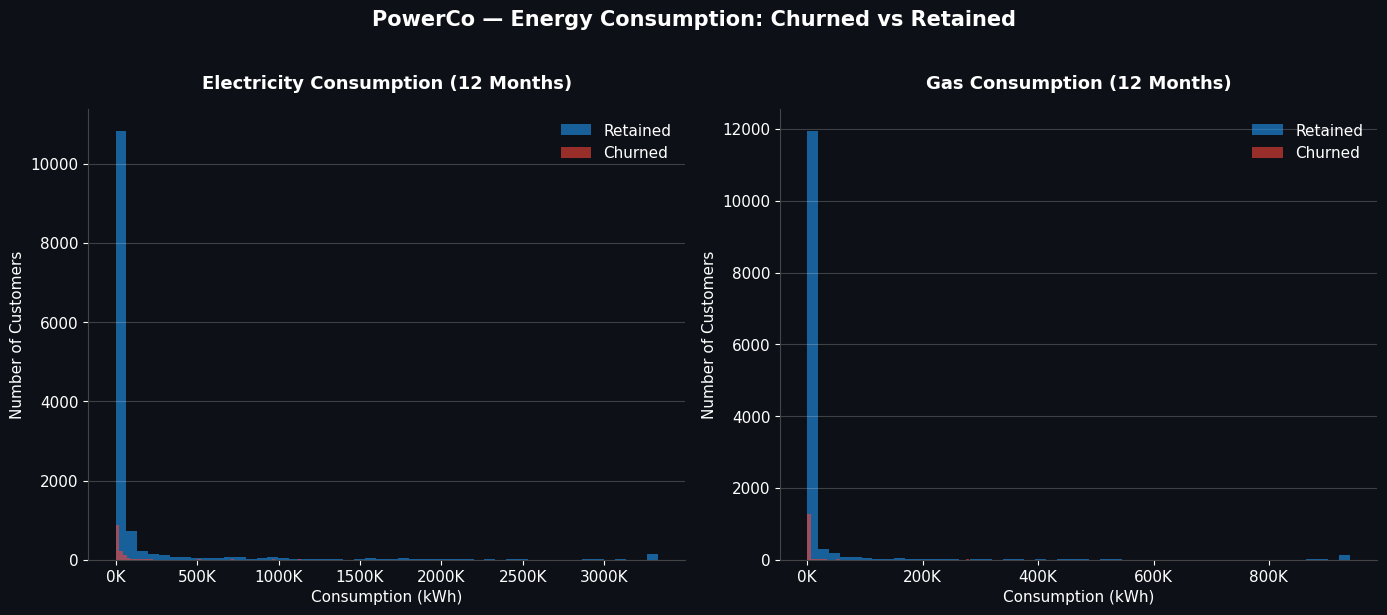

In [7]:
# Consumption analysis — Churned vs Retained
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

for churn_val, label, color in zip([0, 1],
                                    ['Retained', 'Churned'],
                                    ['#2196F3', '#F44336']):
    data = client_df[client_df['churn'] == churn_val]['cons_12m']
    data_clipped = data.clip(upper=data.quantile(0.99))
    axes[0].hist(data_clipped, bins=50, alpha=0.6,
                 label=label, color=color, edgecolor='none')

axes[0].set_title('Electricity Consumption (12 Months)',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Consumption (kWh)', color='white')
axes[0].set_ylabel('Number of Customers', color='white')
axes[0].legend(frameon=False, labelcolor='white')
axes[0].grid(axis='y', alpha=0.2, color='white')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

for churn_val, label, color in zip([0, 1],
                                    ['Retained', 'Churned'],
                                    ['#2196F3', '#F44336']):
    data = client_df[client_df['churn'] == churn_val]['cons_gas_12m']
    data_clipped = data.clip(upper=data.quantile(0.99))
    axes[1].hist(data_clipped, bins=50, alpha=0.6,
                 label=label, color=color, edgecolor='none')

axes[1].set_title('Gas Consumption (12 Months)',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[1].set_xlabel('Consumption (kWh)', color='white')
axes[1].set_ylabel('Number of Customers', color='white')
axes[1].legend(frameon=False, labelcolor='white')
axes[1].grid(axis='y', alpha=0.2, color='white')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.suptitle('PowerCo — Energy Consumption: Churned vs Retained',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('consumption_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

### Key Finding — Energy Consumption

- Both **electricity and gas consumption** distributions are heavily 
  right-skewed — majority of customers consume low energy
- **Churned customers** show similar consumption patterns to retained 
  customers — suggesting consumption alone is NOT a strong predictor of churn
- Most customers consume between **0-100K kWh** of electricity annually
- Gas consumption is even more concentrated near zero — many customers 
  are **electricity-only** customers

## 7. Price Sensitivity Analysis

Now let's analyze the pricing data to understand how prices 
vary across customers and whether price changes correlate 
with churn behavior.

PRICE ANALYSIS:
  Customers with price data : 14,606
  Customers without price   : 0

AVERAGE PRICES — Churned vs Retained:
  Metric                             Retained      Churned
  ------------------------------ ------------ ------------
  price_off_peak_var                   0.1394       0.1388
  price_peak_var                       0.0510       0.0559
  price_off_peak_fix                  43.0760      43.3421
  price_peak_fix                       9.2964      11.1987


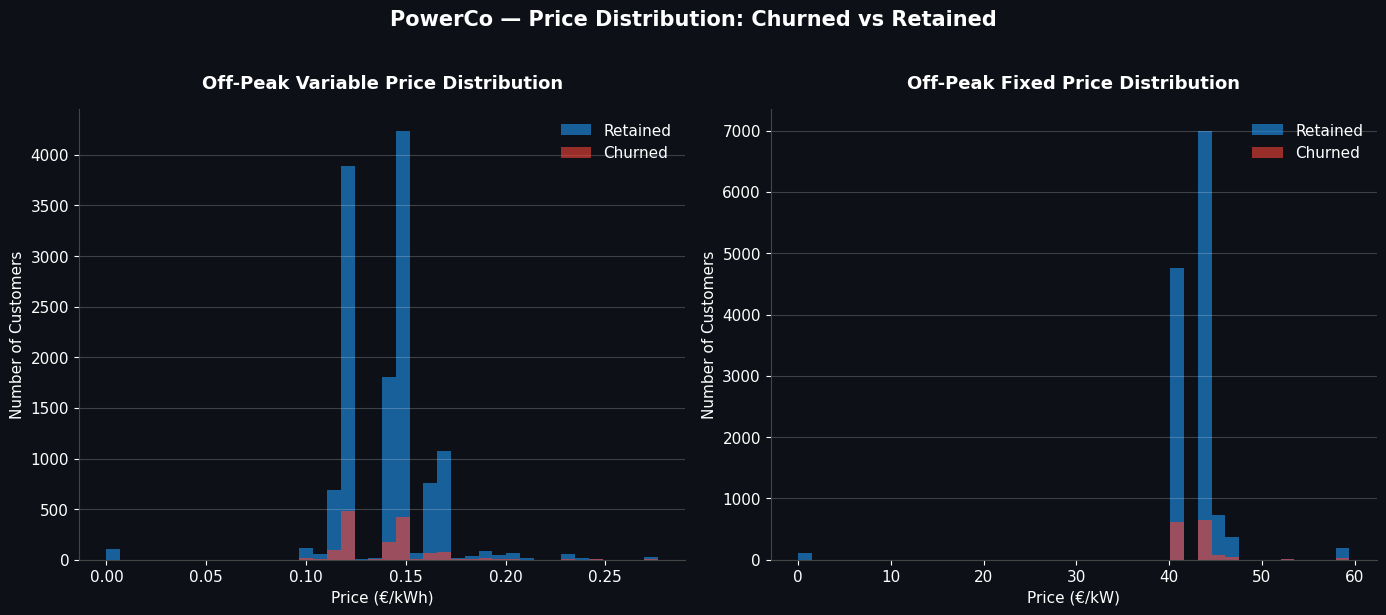

In [8]:
# Parse date column
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

# Get latest price per customer
latest_price = price_df.sort_values('price_date').groupby('id').last().reset_index()

# Merge with client data
merged_df = client_df.merge(latest_price, on='id', how='left')

print("PRICE ANALYSIS:")
print(f"  Customers with price data : {merged_df['price_off_peak_var'].notna().sum():,}")
print(f"  Customers without price   : {merged_df['price_off_peak_var'].isna().sum():,}")

# Avg price by churn status
print(f"\nAVERAGE PRICES — Churned vs Retained:")
print(f"  {'Metric':<30} {'Retained':>12} {'Churned':>12}")
print(f"  {'-'*30} {'-'*12} {'-'*12}")

price_cols = ['price_off_peak_var', 'price_peak_var',
              'price_off_peak_fix', 'price_peak_fix']

for col in price_cols:
    retained = merged_df[merged_df['churn']==0][col].mean()
    churned  = merged_df[merged_df['churn']==1][col].mean()
    print(f"  {col:<30} {retained:>12.4f} {churned:>12.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

# Plot 1 — Off Peak Variable Price
for churn_val, label, color in zip([0, 1],
                                    ['Retained', 'Churned'],
                                    ['#2196F3', '#F44336']):
    data = merged_df[merged_df['churn']==churn_val]['price_off_peak_var'].dropna()
    axes[0].hist(data, bins=40, alpha=0.6,
                 label=label, color=color, edgecolor='none')

axes[0].set_title('Off-Peak Variable Price Distribution',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Price (€/kWh)', color='white')
axes[0].set_ylabel('Number of Customers', color='white')
axes[0].legend(frameon=False, labelcolor='white')
axes[0].grid(axis='y', alpha=0.2, color='white')

# Plot 2 — Off Peak Fixed Price
for churn_val, label, color in zip([0, 1],
                                    ['Retained', 'Churned'],
                                    ['#2196F3', '#F44336']):
    data = merged_df[merged_df['churn']==churn_val]['price_off_peak_fix'].dropna()
    axes[1].hist(data, bins=40, alpha=0.6,
                 label=label, color=color, edgecolor='none')

axes[1].set_title('Off-Peak Fixed Price Distribution',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[1].set_xlabel('Price (€/kW)', color='white')
axes[1].set_ylabel('Number of Customers', color='white')
axes[1].legend(frameon=False, labelcolor='white')
axes[1].grid(axis='y', alpha=0.2, color='white')

plt.suptitle('PowerCo — Price Distribution: Churned vs Retained',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('price_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

### Key Finding — Price Analysis

- **Off-peak variable price** is almost identical for churned (0.1388) 
  and retained (0.1394) customers — very small difference
- **Peak fixed price** shows a notable difference — churned customers 
  pay slightly higher (11.19) vs retained (9.30)
- Price distributions largely overlap between churned and retained customers
- This suggests that **price alone may not be the primary driver of churn**
- However, peak pricing could be a contributing factor worth investigating 
  further in the modeling phase

## 8. Customer Tenure Analysis

Let's investigate whether the length of time a customer has 
been with PowerCo influences their likelihood to churn.

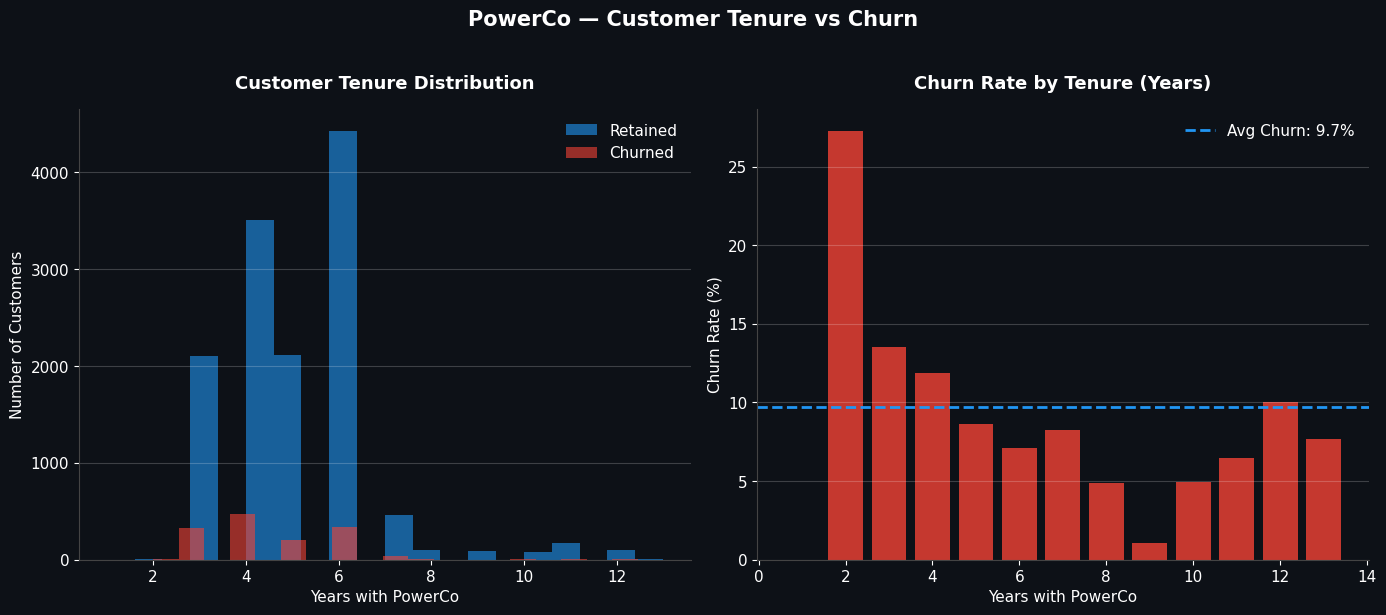

In [9]:
# Tenure analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

# Plot 1 — Tenure Distribution
for churn_val, label, color in zip([0, 1],
                                    ['Retained', 'Churned'],
                                    ['#2196F3', '#F44336']):
    data = client_df[client_df['churn']==churn_val]['num_years_antig']
    axes[0].hist(data, bins=20, alpha=0.6,
                 label=label, color=color, edgecolor='none')

axes[0].set_title('Customer Tenure Distribution',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Years with PowerCo', color='white')
axes[0].set_ylabel('Number of Customers', color='white')
axes[0].legend(frameon=False, labelcolor='white')
axes[0].grid(axis='y', alpha=0.2, color='white')

# Plot 2 — Churn Rate by Tenure
tenure_churn = client_df.groupby('num_years_antig')['churn'].mean() * 100
axes[1].bar(tenure_churn.index, tenure_churn.values,
            color='#F44336', alpha=0.8, edgecolor='none')
axes[1].set_title('Churn Rate by Tenure (Years)',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[1].set_xlabel('Years with PowerCo', color='white')
axes[1].set_ylabel('Churn Rate (%)', color='white')
axes[1].grid(axis='y', alpha=0.2, color='white')

# Average line
avg_churn = client_df['churn'].mean() * 100
axes[1].axhline(y=avg_churn, color='#2196F3',
                linestyle='--', linewidth=2,
                label=f'Avg Churn: {avg_churn:.1f}%')
axes[1].legend(frameon=False, labelcolor='white')

plt.suptitle('PowerCo — Customer Tenure vs Churn',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('tenure_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

### Key Finding — Customer Tenure

- Customers with **1-2 years** tenure have the highest churn rate (~27%)
- Churn rate **decreases significantly** as tenure increases
- Customers with **6+ years** show below-average churn
- This suggests **newer customers are most at risk** of churning
- Tenure is likely a **stronger predictor** of churn than price

## 9. Net Margin Analysis

Let's analyze the net margin of churned vs retained customers 
to understand the financial impact of churn on PowerCo's business.

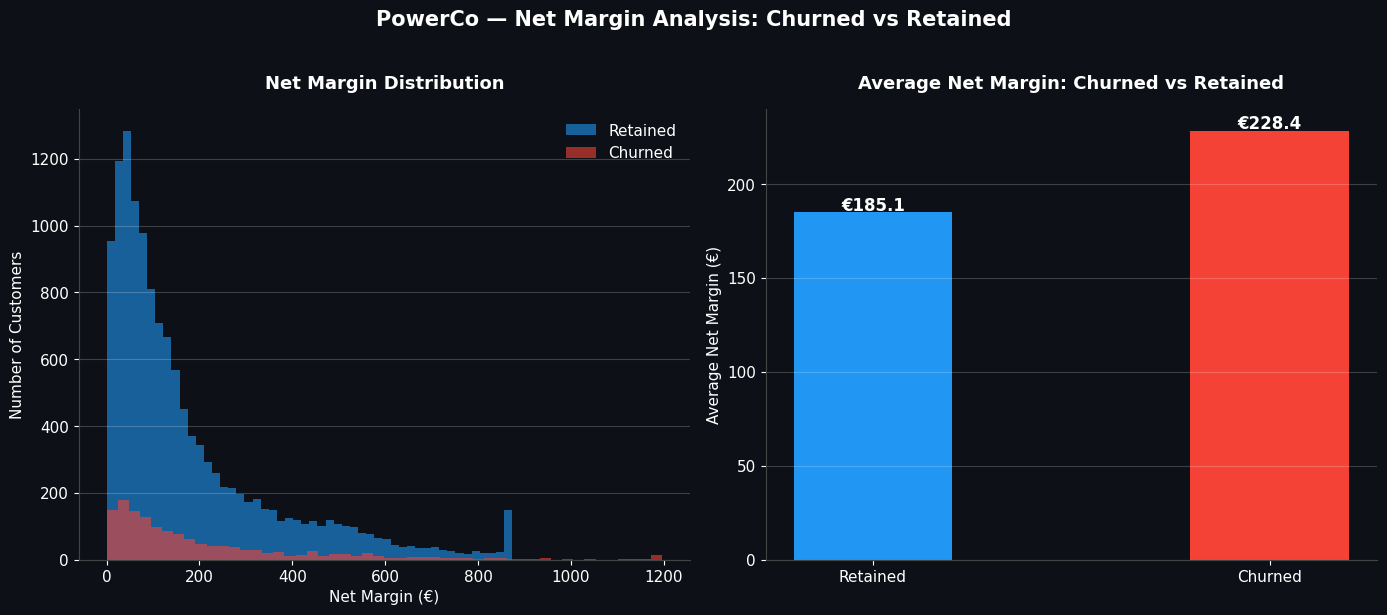

In [10]:
# Net Margin Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

# Plot 1 — Net Margin Distribution
for churn_val, label, color in zip([0, 1],
                                    ['Retained', 'Churned'],
                                    ['#2196F3', '#F44336']):
    data = client_df[client_df['churn']==churn_val]['net_margin']
    data_clipped = data.clip(upper=data.quantile(0.99))
    axes[0].hist(data_clipped, bins=50, alpha=0.6,
                 label=label, color=color, edgecolor='none')

axes[0].set_title('Net Margin Distribution',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Net Margin (€)', color='white')
axes[0].set_ylabel('Number of Customers', color='white')
axes[0].legend(frameon=False, labelcolor='white')
axes[0].grid(axis='y', alpha=0.2, color='white')

# Plot 2 — Avg Net Margin by Churn
avg_margin = client_df.groupby('churn')['net_margin'].mean()
colors_bar = ['#2196F3', '#F44336']
bars = axes[1].bar(['Retained', 'Churned'],
                    avg_margin.values,
                    color=colors_bar,
                    edgecolor='none',
                    width=0.4)
axes[1].set_title('Average Net Margin: Churned vs Retained',
                   fontsize=13, fontweight='bold', color='white', pad=15)
axes[1].set_ylabel('Average Net Margin (€)', color='white')
axes[1].grid(axis='y', alpha=0.2, color='white')
for bar, val in zip(bars, avg_margin.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 1, f'€{val:.1f}',
                 ha='center', color='white',
                 fontweight='bold', fontsize=12)

plt.suptitle('PowerCo — Net Margin Analysis: Churned vs Retained',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('margin_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

### Key Finding — Net Margin Analysis

- **Churned customers** have a **higher average net margin (€228.4)** 
  compared to retained customers (€185.1)
- This is a critical business insight — PowerCo is **losing its most 
  profitable customers** to competitors
- This makes churn even more urgent to address — it's not just about 
  volume of customers lost, but the **quality and value** of customers lost
- Targeting high-margin customers with retention strategies should be 
  a top priority for PowerCo

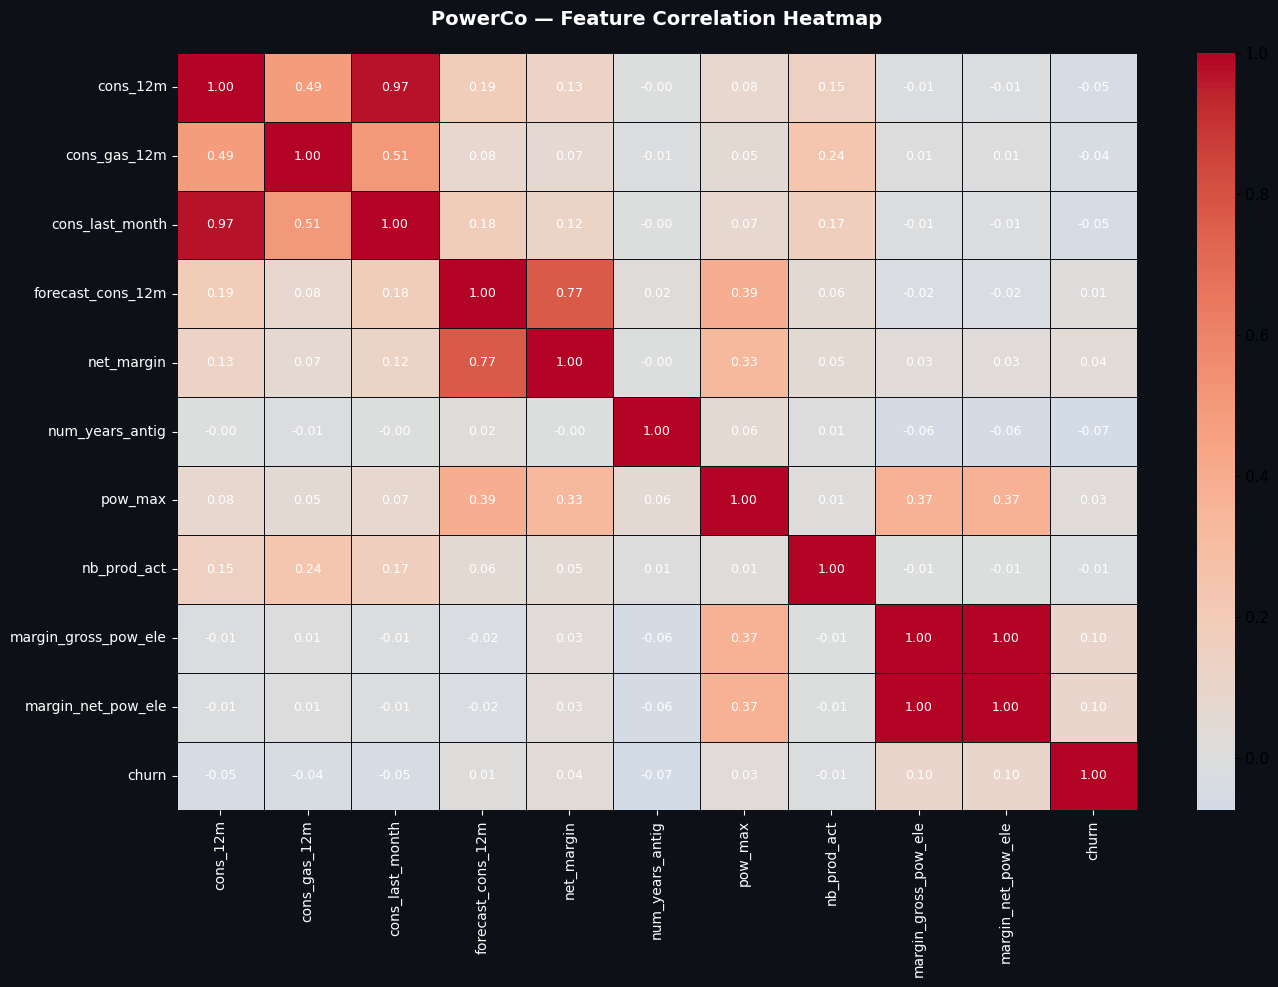

In [11]:
# Correlation Heatmap
numeric_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month',
                'forecast_cons_12m', 'net_margin', 'num_years_antig',
                'pow_max', 'nb_prod_act', 'margin_gross_pow_ele',
                'margin_net_pow_ele', 'churn']

corr_matrix = client_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

sns.heatmap(corr_matrix,
            annot     = True,
            fmt       = '.2f',
            cmap      = 'coolwarm',
            center    = 0,
            ax        = ax,
            linewidths= 0.5,
            linecolor = '#0D1117',
            annot_kws = {'size': 9, 'color': 'white'})

ax.set_title('PowerCo — Feature Correlation Heatmap',
             fontsize=14, fontweight='bold',
             color='white', pad=20)
ax.tick_params(colors='white', labelsize=10)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

### Key Finding — Correlation Analysis

- **Churn has very low correlation** with most features — confirming 
  that no single variable alone drives churn
- **cons_12m and cons_last_month** are highly correlated (0.97) — 
  multicollinearity to handle during modeling
- **forecast_cons_12m and net_margin** show strong correlation (0.77) — 
  higher forecasted consumption = higher margin
- **num_years_antig (tenure)** has near-zero correlation with churn (-0.07) 
  — but churn rate by tenure chart showed clear pattern — non-linear relationship
- **Price sensitivity alone cannot explain churn** — multiple factors 
  at play — a predictive model is needed

### Overall EDA Conclusions

**1. Churn Rate**
- 9.7% of customers churned — 1,419 out of 14,606 customers
- Imbalanced dataset — needs special handling during modeling

**2. Price Sensitivity**
- Price differences between churned and retained customers are minimal
- Off-peak variable price: Churned (0.1388) vs Retained (0.1394)
- **Price alone does NOT appear to be the primary driver of churn**

**3. Customer Tenure**
- Newest customers (1-2 years) have the highest churn rate (~27%)
- Tenure is a stronger indicator of churn risk than price

**4. Net Margin**
- Churned customers have higher net margin (€228) vs retained (€185)
- PowerCo is losing its most valuable customers — urgent action needed

**5. Energy Consumption**
- Similar consumption patterns between churned and retained customers
- Consumption alone is not a reliable churn predictor

**6. Recommendation**
- Price sensitivity hypothesis is **partially supported but not conclusive**
- A **Random Forest classification model** should be built using multiple 
  features to accurately predict churn
- Feature engineering on price changes over time may reveal deeper 
  price sensitivity signals